In [27]:
import os
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
# path = r'd:\Projects\Tr_lights\data\20250512_131114_ann\20250512_131114_c0\9194.296.jpg'
path = r'./image.jpg'
img = Image.open(path)
img = np.array(img, dtype=np.uint8)
img.shape

(720, 1280, 3)

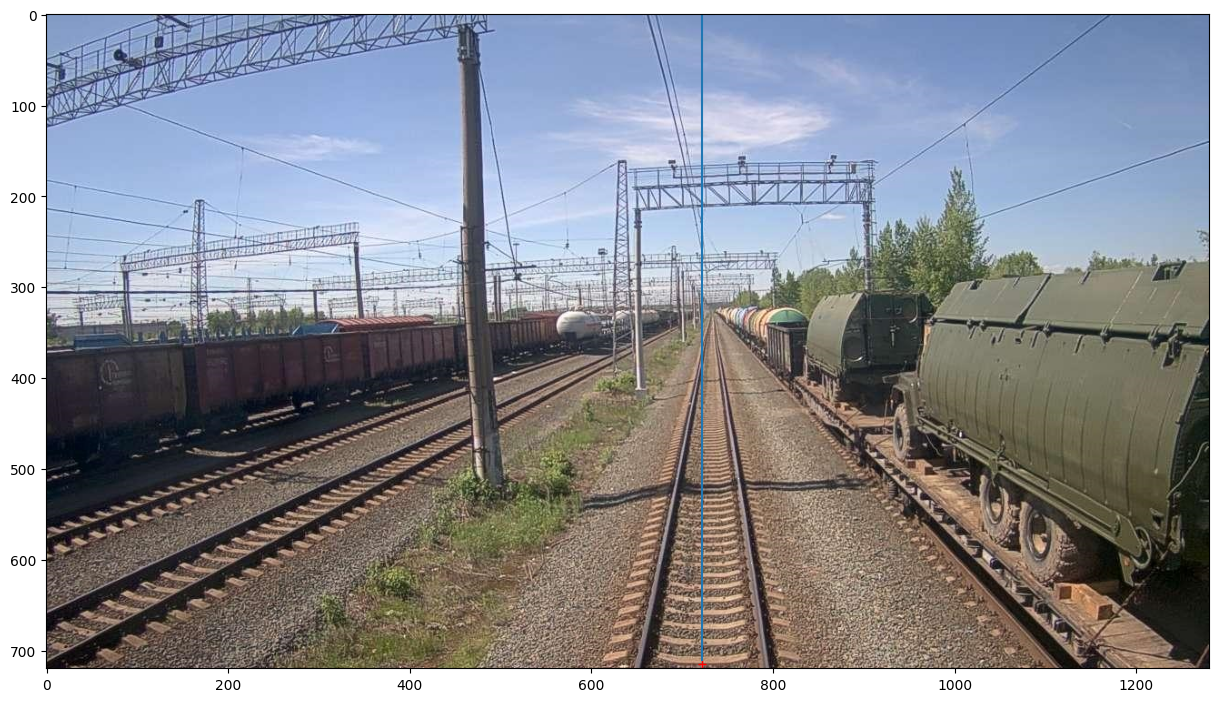

In [3]:
#  центр колеи
plt.figure(figsize=(15, 10))
plt.imshow(img)
x_c = 722
plt.plot([x_c], [715], marker='+', color='red', linewidth=0)
plt.plot([x_c, x_c], [0, 710])


x_min, x_max, y_min, y_max -4064.3643 5543.171 381.40195 12494.898


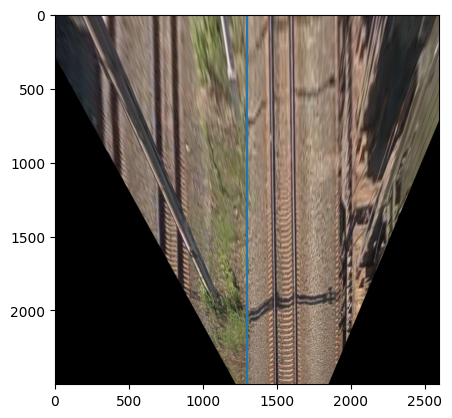

In [ ]:
# # первый вариант

# img = Image.open(r'./image.jpg')
# img = np.array(img)[320:,400:1000,:]
# w, h = img.shape[1], img.shape[0]
# # Координаты углов трапеции по картинке (тут получены вручную)
# top_left = [230, 158]
# top_right = [470, 158]
# bottom_left = [155, 260]
# bottom_right = [558, 260]

# img_points = np.float32([top_left, top_right, bottom_left, bottom_right])
# wmm = 200
# hmm = 250
# real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# # Вычисление матрицы коррекции перспективы
# pmatrix = cv.getPerspectiveTransform(img_points, real_pointst)

# # выпрямленная картинка в пределах угла трапеции
# cropped = cv.warpPerspective(img, pmatrix, (wmm, hmm))
# # Пересчет всей картинки (не только в пределах координат трапеции)

# # Углы исходной каринки
# corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# # Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
# t_corners = cv.perspectiveTransform(corners, pmatrix)
# # Границы изображения в реальном пространстве
# x_min, y_min = t_corners.min(axis=0).ravel()
# x_max, y_max = t_corners.max(axis=0).ravel()
# print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# # Размеры области
# new_w = int(np.ceil(x_max - x_min))
# new_h = int(np.ceil(y_max - y_min))

# # Матрица переноса (сдвиг картинки в положительную область
# pmatrix_shift = np.array([[3, 0, 1300],
#                           [0, 2.5, 1600],
#                           [0, 0, 1]])
# # Произведение матрицы переноса и матрицы перспективы
# pmatrix_new = pmatrix_shift @ pmatrix

# # полная картинка
# corr = cv.warpPerspective(np.array(img), pmatrix_new, (2600, 2500))

# plt.imshow(corr)
# x = corr.shape[1] // 2
# plt.plot([x, x], [0, corr.shape[0]-1])

(400, 600, 3)


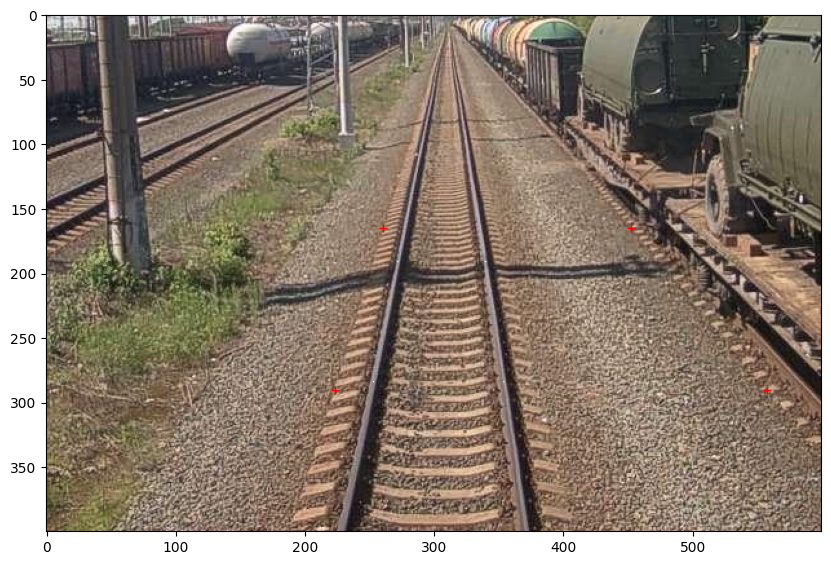

In [4]:
img = Image.open(r'./image.jpg')
img = np.array(img)
img = img[320:, x_c-300:x_c+300,:]
w, h = img.shape[1], img.shape[0]

fig, (asrc) = plt.subplots(1, 1, figsize=(10, 8))

# Координаты углов трапеции по картинке (тут получены вручную)
top_left = [260, 165]
top_right = [452, 165]
bottom_left = [223, 290]
bottom_right = [558, 290]

img_points = np.float32([top_left, top_right, bottom_left, bottom_right])

# Показать кординаты углов на картинке
asrc.imshow(img)
asrc.plot(*img_points.T, marker='+', color='red', linewidth=0)
print(img.shape)

200 411
(411, 200, 3)


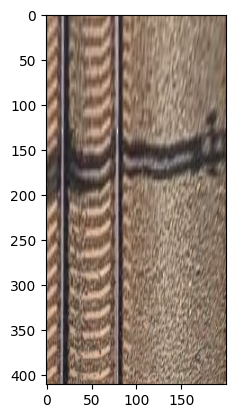

In [5]:
# wmm = 150
# hmm = 222
wmm = 200
hmm = int(wmm * 2.055)
print(wmm, hmm)
real_pointst = np.float32([[0, 0], [wmm, 0], [0, hmm], [wmm, hmm]])

# Вычисление матрицы коррекции перспективы
pmatrix = cv.getPerspectiveTransform(img_points, real_pointst)

# выпрямленная картинка в пределах угла трапеции
cropped = cv.warpPerspective(img, pmatrix, (wmm, hmm))

# Показать выпрямленную картинку
# plt.axis('equal')
plt.imshow(cropped)
print(cropped.shape)

x_min, x_max, y_min, y_max -19064.197 17972.84 -56093.89 561.6869
(2400, 2600, 3)


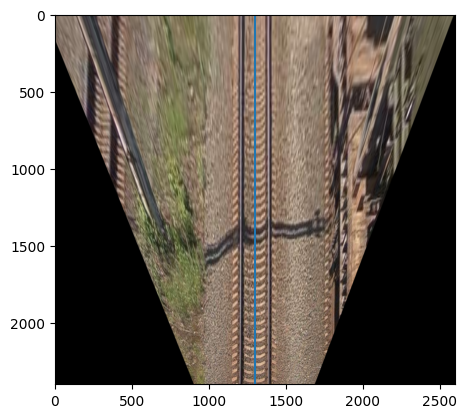

In [24]:
# Пересчет всей картинки (не только в пределах координат трапеции)

# Углы исходной каринки
corners = np.float32([[0, 0], [w, 0], [0, h], [w, h]]).reshape(-1, 1, 2)
# Положение этих точек в реальном пространстве (применяем к ним матрицу коррекции перспективы)
t_corners = cv.perspectiveTransform(corners, pmatrix)
# Границы изображения в реальном пространстве
x_min, y_min = t_corners.min(axis=0).ravel()
x_max, y_max = t_corners.max(axis=0).ravel()
print('x_min, x_max, y_min, y_max', x_min, x_max, y_min, y_max)
# Размеры области
new_w = int(np.ceil(x_max - x_min))
new_h = int(np.ceil(y_max - y_min))

# Матрица переноса (сдвиг картинки в положительную область
# pmatrix_shift = np.array([[1, 0, -x_min],
#                           [0, 1, -y_min],
#                           [0, 0, 1]])
# pmatrix_new = pmatrix @ pmatrix_shift
# corr = cv.warpPerspective(np.array(img), pmatrix_new, (new_w, new_h))

pmatrix_shift = np.array([[3, 0, 1150],
                          [0, 2.5, 1000],
                          [0, 0, 1]])

# # Матрица переноса (сдвиг картинки в положительную область
pmatrix_new = pmatrix_shift @ pmatrix

# # полная картинка
corr = cv.warpPerspective(np.array(img), pmatrix_new, (2600, 2400))

plt.imshow(corr)
x = corr.shape[1] // 2
plt.plot([x, x], [0, corr.shape[0]-1])

print(corr.shape)


In [71]:
src = r'./data/2'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

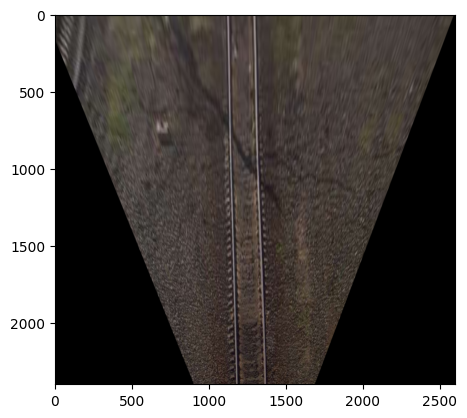

In [72]:
img2 = Image.open(img_fs[9])
# img2 = Image.open(r'data/2/16069.180.jpg')
img2 = np.array(img2)
img2 = img2[320:, x_c-300:x_c+300,:]
corr2 = cv.warpPerspective(np.array(img2), pmatrix_new, (2600, 2400))
plt.imshow(corr2)

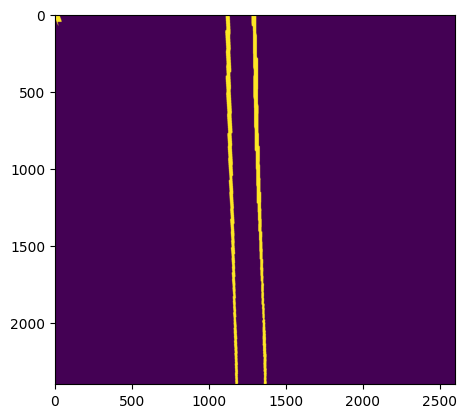

In [78]:
mask = np.load(msk_fs[9])
mask = mask[320:, x_c-300:x_c+300]
mask_c = cv.warpPerspective(np.array(mask), pmatrix_new, (2600, 2400))
plt.imshow(mask_c)


(29, 1500)

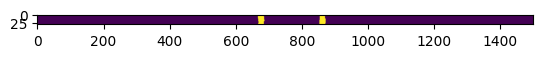

In [80]:
plt.imshow(mask_c[-30:-1, 500:2000])
mask_c[-30:-1, 500:2000].shape

In [ ]:
mask_all = np.zeros((1, 1500))
for f in msk_fs:
    mask = np.load(f)
    mask = mask[320:, x_c-300:x_c+300]
    mask_c = cv.warpPerspective(np.array(mask), pmatrix_new, (2600, 2400))
    mask_all = np.vstack((mask_all, mask_c[-30:-1, 500:2000]))


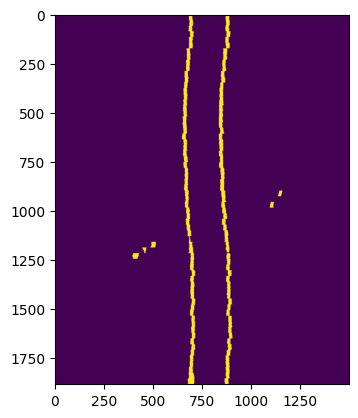

In [88]:
plt.imshow(mask_all)